# AnalystLab Africa Internship — Week 1-2
## Dataset 2: Netflix Movies & TV Shows — Data Cleaning & EDA
### Name: Sakiru Akinpelu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('netflix_titles.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (8807, 12)


In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [5]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [6]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [7]:
print(f"Duplicate rows: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows: 0
Shape after removing duplicates: (8807, 12)


In [8]:
df['director'] = df['director'].fillna('Unknown')
print("Missing directors filled ✅")

Missing directors filled ✅


In [9]:
df['cast'] = df['cast'].fillna('Unknown')
print("Missing cast filled ✅")

Missing cast filled ✅


In [10]:
df['country'] = df['country'].fillna('Unknown')
print("Missing country filled ✅")

Missing country filled ✅


In [11]:
df = df.dropna(subset=['date_added', 'rating', 'duration'])
print(f"Shape after dropping missing date/rating/duration: {df.shape}")

Shape after dropping missing date/rating/duration: (8790, 12)


In [12]:
# Strip whitespace and convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())

print(df['date_added'].dtype)
print("Date column converted successfully ✅")

datetime64[ns]
Date column converted successfully ✅


In [13]:
# Standardize text to title case and strip spaces
df['type'] = df['type'].str.strip().str.title()
df['country'] = df['country'].str.strip().str.title()
df['rating'] = df['rating'].str.strip()

print("Text columns standardized ✅")

Text columns standardized ✅


In [14]:
# Extract year and month content was added to Netflix
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

print("Year and Month columns extracted ✅")
df.head()

Year and Month columns extracted ✅


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,September
1,s2,Tv Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,September
2,s3,Tv Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,September
3,s4,Tv Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,September
4,s5,Tv Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,September


In [15]:
df.to_csv('cleaned_netflix.csv', index=False)
print(f"Cleaned dataset saved! ✅")
print(f"Final shape: {df.shape}")

Cleaned dataset saved! ✅
Final shape: (8790, 14)


In [16]:
print("======= NETFLIX DATASET SUMMARY =======\n")
print(f"Total Titles: {df.shape[0]:,}")
print(f"Movies: {df[df['type'] == 'Movie'].shape[0]:,}")
print(f"TV Shows: {df[df['type'] == 'TV Show'].shape[0]:,}")
print(f"Unique Countries: {df['country'].nunique():,}")
print(f"Unique Ratings: {df['rating'].nunique()}")
print(f"Release Year Range: {df['release_year'].min()} – {df['release_year'].max()}")
print(f"Date Range Added: {df['date_added'].min().strftime('%B %Y')} – {df['date_added'].max().strftime('%B %Y')}")

======= NETFLIX DATASET SUMMARY =======

Total Titles: 8,790
Movies: 6,126
TV Shows: 0
Unique Countries: 749
Unique Ratings: 14
Release Year Range: 1925 – 2021
Date Range Added: January 2008 – September 2021


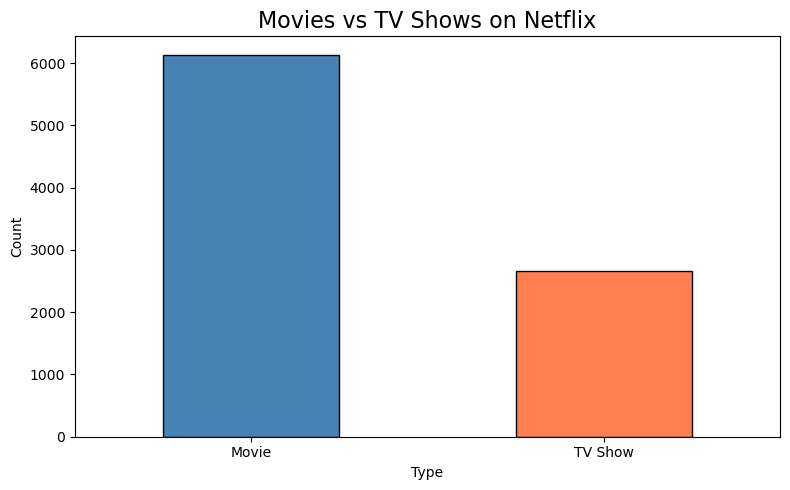

Chart saved! ✅


In [28]:
plt.figure(figsize=(8, 5))
df['type'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Movies vs TV Shows on Netflix', fontsize=16)
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('movies_vs_tvshows.png')
plt.show()
print("Chart saved! ✅")

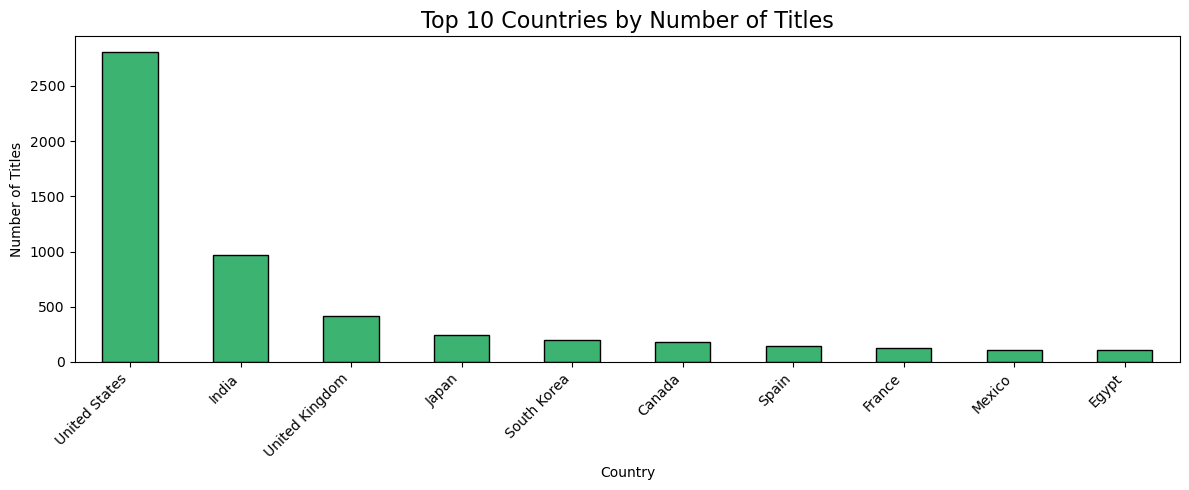

Chart saved! ✅


In [18]:
# Exclude Unknown
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_countries.plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Top 10 Countries by Number of Titles', fontsize=16)
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_countries_netflix.png')
plt.show()
print("Chart saved! ✅")

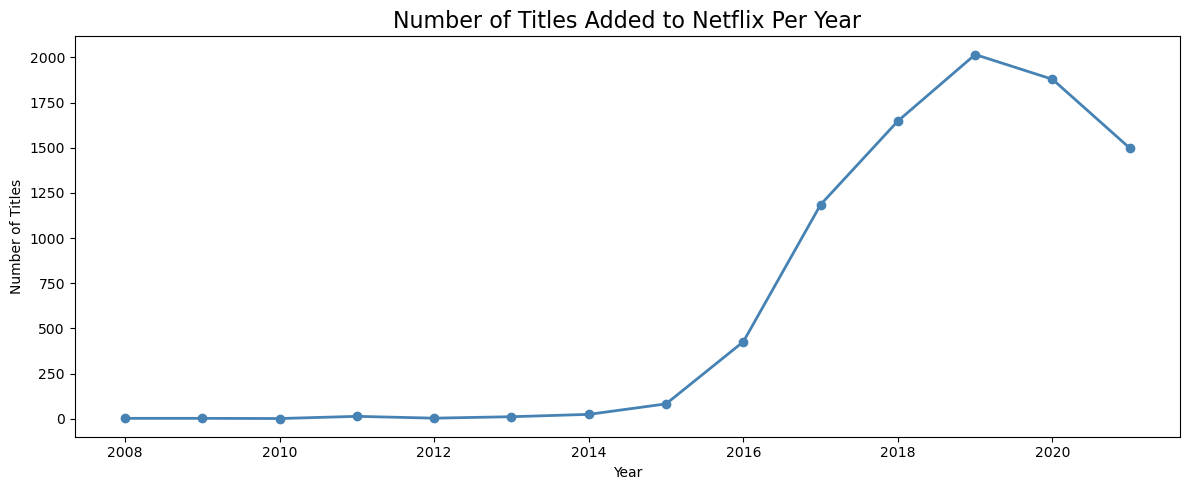

Chart saved! ✅


In [19]:
content_per_year = df.groupby('year_added')['title'].count()

plt.figure(figsize=(12, 5))
plt.plot(content_per_year.index, content_per_year.values, marker='o', color='steelblue', linewidth=2)
plt.title('Number of Titles Added to Netflix Per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.tight_layout()
plt.savefig('content_per_year.png')
plt.show()
print("Chart saved! ✅")

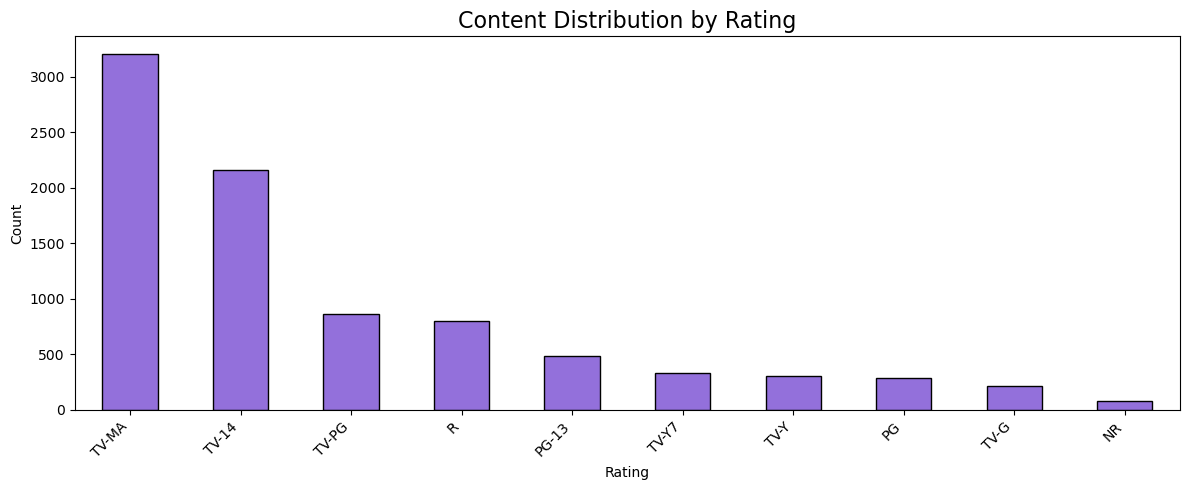

Chart saved! ✅


In [27]:
top_ratings = df['rating'].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_ratings.plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Content Distribution by Rating', fontsize=16)
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('ratings_distribution.png')
plt.show()
print("Chart saved! ✅")

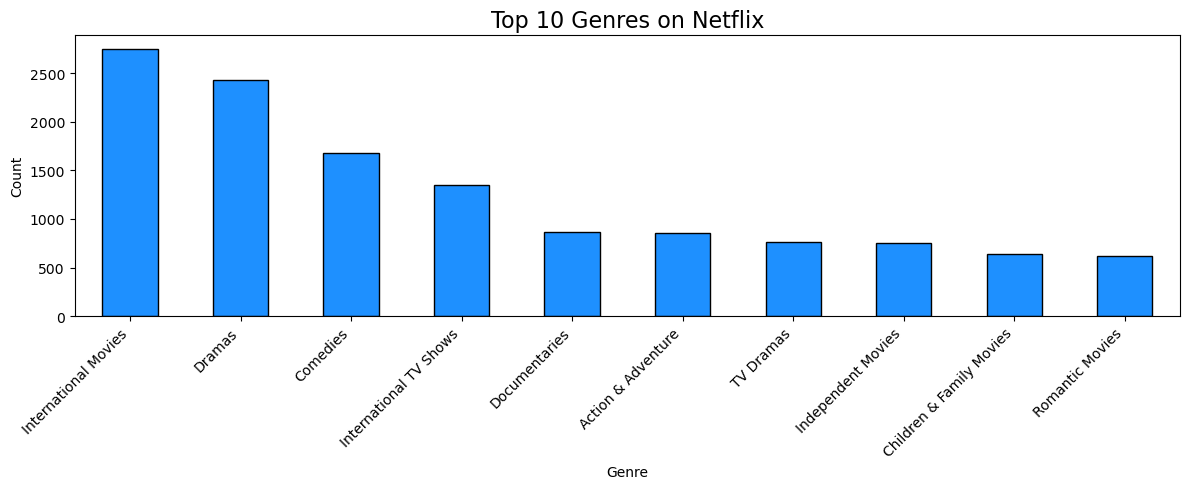

Chart saved! ✅


In [26]:
# listed_in contains multiple genres separated by commas — split and count each
from collections import Counter

all_genres = df['listed_in'].str.split(', ').explode()
top_genres = pd.Series(Counter(all_genres)).sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
top_genres.plot(kind='bar', color='dodgerblue', edgecolor='black')
plt.title('Top 10 Genres on Netflix', fontsize=16)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_genres.png')
plt.show()
print("Chart saved! ✅")

In [22]:
df['type'].value_counts()

type
Movie      6126
Tv Show    2664
Name: count, dtype: int64

In [23]:
print(df['type'].unique())

['Movie' 'Tv Show']


In [24]:
# Fix the Tv Show casing issue
df['type'] = df['type'].replace('Tv Show', 'TV Show')

# Verify the fix
print(df['type'].value_counts())

type
Movie      6126
TV Show    2664
Name: count, dtype: int64


In [25]:
print("======= NETFLIX DATASET SUMMARY =======\n")
print(f"Total Titles: {df.shape[0]:,}")
print(f"Movies: {df[df['type'] == 'Movie'].shape[0]:,}")
print(f"TV Shows: {df[df['type'] == 'TV Show'].shape[0]:,}")
print(f"Unique Countries: {df['country'].nunique():,}")
print(f"Unique Ratings: {df['rating'].nunique()}")
print(f"Release Year Range: {df['release_year'].min()} – {df['release_year'].max()}")
print(f"Date Range Added: {df['date_added'].min().strftime('%B %Y')} – {df['date_added'].max().strftime('%B %Y')}")

======= NETFLIX DATASET SUMMARY =======

Total Titles: 8,790
Movies: 6,126
TV Shows: 2,664
Unique Countries: 749
Unique Ratings: 14
Release Year Range: 1925 – 2021
Date Range Added: January 2008 – September 2021
